In [ ]:
!pip install "textdistance[extras]"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.7 MB/s eta 0:00:00


In [ ]:
!pip install transformers==4.57.1
!pip install torch pillow einops torchvision accelerate decord2 molmo_utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.8 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.0
    Uninstalling huggingface_hub-1.4.0:
      Successfully uninstalled huggingface_hub-1.4.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 40.0 MB/s eta 0:00:00


In [ ]:
import os
import io
import re
import ast
import json
import torch
import contextlib
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from PIL import Image
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoProcessor,
    AutoModelForImageTextToText
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

JUDGE_MODEL_ID = "allenai/Molmo2-8B"
_JUDGE_MODEL = None
_JUDGE_PROCESSOR = None

def get_molmo_model():
    global _JUDGE_MODEL, _JUDGE_PROCESSOR
    if _JUDGE_MODEL is None:
        _JUDGE_PROCESSOR = AutoProcessor.from_pretrained(
            JUDGE_MODEL_ID,
            trust_remote_code=True
        )
        _JUDGE_MODEL = AutoModelForImageTextToText.from_pretrained(
            JUDGE_MODEL_ID,
            trust_remote_code=True,
            torch_dtype=torch.bfloat16,
            device_map="auto"
        )
    return _JUDGE_PROCESSOR, _JUDGE_MODEL

JUDGE_SYSTEM_PROMPT = """
You are a Data Visualization Expert acting as a strict judge.
Your task is to evaluate a generated Chart/Graph against a User Request.

Evaluation Criteria:
1. RELEVANCE: Does the chart visually represent the data asked for? (correct variables, time period).
2. INFORMATION READABILITY: Is it user-friendly? (No IDs for labels, simple numbers, no scientific notation like 1e6, proper scaling).
3. ADAPTABILITY: Is the chart type optimal? (e.g., would a Stacked Bar, Area, or Bubble chart be significantly better?).
4. LEGEND READABILITY: Precise design? (Wise axis choices, distinct colors for types, perfect legend placement/text size).
5. COLOR CHOICE: Are colors significant? (Gradual colors for increasing values, meaningful color-coding).

Output ONLY a valid JSON object in this format:
{
  "relevance": boolean,
  "information_readability": boolean,
  "adaptability": boolean,
  "legend_readability": boolean,
  "color_choice": boolean,
  "reasoning": "string" (1 sentence for the explication of each criteria)
}
"""

def extract_part(prompt, key):
    """
    Helper to extract the prompt content (e.g., 'User Request')
    from the structured prompt string.
    """
    search_key = f"{key}:"
    if search_key in prompt:
        return prompt.split(search_key)[-1].replace("<|im_end|>", "").strip()
    return prompt

def vlm_evaluate_image(prompt, image,return_details=False):
    """Calls Molmo to judge the image based on 5 precise visual criteria."""
    processor, model = get_molmo_model()

    question_text = extract_part(prompt, "User Request")

    full_text = (
        f"{JUDGE_SYSTEM_PROMPT}\n\n"
        f"User Request: {question_text}\n"
        f"Evaluate this chart strictly according to the 5 criteria above."
    )

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": full_text},
                {"type": "image", "image": image}
            ]
        }
    ]

    try:
        inputs = processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors="pt",
            return_dict=True,
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=300,
                do_sample=False,
                temperature=0.0
            )

        generated_text = processor.tokenizer.decode(
            output_ids[0, inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )

        clean_json = generated_text.replace("```json", "").replace("```", "").strip()
        json_match = re.search(r'\{.*\}', clean_json, re.DOTALL)

        if not json_match:
          if return_details:
            return [0, 0, 0, 0, 0, 0],"JSON parsing failed"
          return 0.0, "JSON parsing failed"

        result = json.loads(json_match.group(0))

        if not result.get('relevance', False):
          if return_details:
            return [0, 0, 0, 0, 0, 0],f"Irrelevant: {result.get('reasoning', '')}"
          return 0.0, f"Irrelevant: {result.get('reasoning', '')}"

        score = 0.5  # Base score for being relevant

        if result.get('information_readability', False):
            score += 0.5
        if result.get('adaptability', False):
            score += 0.4
        if result.get('legend_readability', False):
            score += 0.3
        if result.get('color_choice', False):
            score += 0.3
        if return_details:
          return [result.get('relevance', False),result.get('information_readability', False),result.get('adaptability', False),result.get('adaptability', False),result.get('legend_readability', False),result.get('color_choice', False),score],result.get('reasoning', "No reasoning provided")
        return score, result.get('reasoning', "No reasoning provided")


    except Exception as e:
        print(f"VLM Error: {e}")
        if return_details:
          return [0, 0, 0, 0, 0, 0],f"Error: {str(e)}"
        return 0.0, f"Error: {str(e)}"

In [ ]:
#@ class de création de la base SQL

import pandas as pd
import sqlite3
import glob
import os

class GDELTValidator:
    def __init__(self, path_mentions, path_export):
        self.path_mentions = path_mentions
        self.path_export = path_export
        self.events = None
        self.mentions = None

        # Column Definitions
        self.COL_NAMES_MENTIONS = [
            "GlobalEventID", "EventTimeDate", "MentionTimeDate", "MentionType",
            "MentionSourceName", "MentionIdentifier", "SentenceID",
            "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset",
            "InRawText", "Confidence", "MentionDocLen", "MentionDocTone",
            "SRCLC", "ENG"
        ]

        self.COL_NAMES_EVENTS = [
            "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
            "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
            "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
            "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
            "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
            "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
            "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
            "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
            "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
            "Actor1Geo_Type", "Actor1Geo_Fullname", "Actor1Geo_CountryCode",
            "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
            "Actor1Geo_Long", "Actor1Geo_FeatureID",
            "Actor2Geo_Type", "Actor2Geo_Fullname", "Actor2Geo_CountryCode",
            "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
            "Actor2Geo_Long", "Actor2Geo_FeatureID",
            "ActionGeo_Type", "ActionGeo_Fullname", "ActionGeo_CountryCode",
            "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
            "ActionGeo_Long", "ActionGeo_FeatureID", "DATEADDED", "SOURCEURL"
        ]

    def load_data(self):
        """Loads the CSVs into pandas DataFrames."""
        print("--- Loading Events ---")
        self.events = self._load_files(
            self.path_export,
            "*.export.CSV",
            self.COL_NAMES_EVENTS,
            {"GlobalEventID": "string", "EventCode": "string"}
        )
        print(f"Total Events loaded: {len(self.events)}")

        print("--- Loading Mentions ---")
        self.mentions = self._load_files(
            self.path_mentions,
            "*.mentions.CSV",
            self.COL_NAMES_MENTIONS,
            {"GlobalEventID": "string"}
        )
        print(f"Total Mentions loaded: {len(self.mentions)}")

    def _load_files(self, directory, file_pattern, col_names, dtype_dict):
        search_path = os.path.join(directory, file_pattern)
        files = glob.glob(search_path)[0:2]

        if not files:
            print(f"Warning: No files found in {search_path}")
            return pd.DataFrame(columns=col_names)

        df_list = []
        for filename in files:
            try:
                df = pd.read_csv(
                    filename, sep="\t", names=col_names, dtype=dtype_dict, on_bad_lines='skip'
                )
                df_list.append(df)
            except Exception as e:
                print(f"Error loading {filename}: {e}")

        if df_list:
            return pd.concat(df_list, ignore_index=True)
        return pd.DataFrame(columns=col_names)

    def push_to_sqlite(self, conn):
        """
        Takes an active sqlite3 connection and writes the dataframes to it.
        This creates tables named 'events' and 'mentions'.
        """
        if self.events is not None:
            self.events.to_sql("events", conn, if_exists="replace", index=False)
        if self.mentions is not None:
            self.mentions.to_sql("mentions", conn, if_exists="replace", index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mentions_folder_path = '/content/drive/MyDrive/GDELT_dataset/GDELT_export_mentions'
mentions_events_path = '/content/drive/MyDrive/GDELT_dataset/GDELT_export_events'

validator = GDELTValidator(mentions_folder_path, mentions_events_path)
validator.load_data()

--- Loading Events ---
Total Events loaded: 2674
--- Loading Mentions ---
Total Mentions loaded: 3913


In [ ]:
csv_path_gt = '/content/drive/MyDrive/gdelt_viz_dataset.csv'
df_gt = pd.read_csv(csv_path_gt)
df_gt.head()

,id,text_query,sql_query,query_result,visualization_code
0,1,Pays avec le plus grand nombre d'événements im...,"SELECT Actor1CountryCode, COUNT(*) AS nb_evene...","[{""Actor1CountryCode"":""USA"",""nb_evenements"":14...",import matplotlib.pyplot as plt\nimport seabor...
1,2,Sources de nouvelles mentionnant le plus d'évé...,"SELECT MentionSourceName, COUNT(DISTINCT Globa...","[{""MentionSourceName"":""yahoo.com"",""nb_evenemen...",import matplotlib.pyplot as plt\nimport seabor...
2,3,Tendances mensuelles du nombre total d'articles,"SELECT MonthYear, SUM(NumArticles) AS total_ar...","[{""MonthYear"":202310,""total_articles"":47685},{...",import matplotlib.pyplot as plt\nimport seabor...
3,4,Pays avec le ton moyen le plus positif dans le...,"SELECT Actor1CountryCode, AVG(AvgTone) AS ton_...","[{""Actor1CountryCode"":""MHL"",""ton_moyen"":7.5471...",import matplotlib.pyplot as plt\nimport seabor...
4,5,Événements ayant le plus grand écart entre ton...,"SELECT e.GlobalEventID, e.AvgTone - AVG(m.Ment...","[{""GlobalEventID"":""1130323692"",""difference_ton...",import matplotlib.pyplot as plt\nimport seabor...


Processing row 51 (1/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Processing row 481 (2/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



...

Processing row 741 (35/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Processing row 49 (36/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 1124 (37/100)...
Available columns: ['GlobalEventID', 'Actor2Name']
Using event code column: None
Using actor column: Actor2Name
Could not find required columns in the dataframe.
Available columns: ['GlobalEventID', 'Actor2Name']


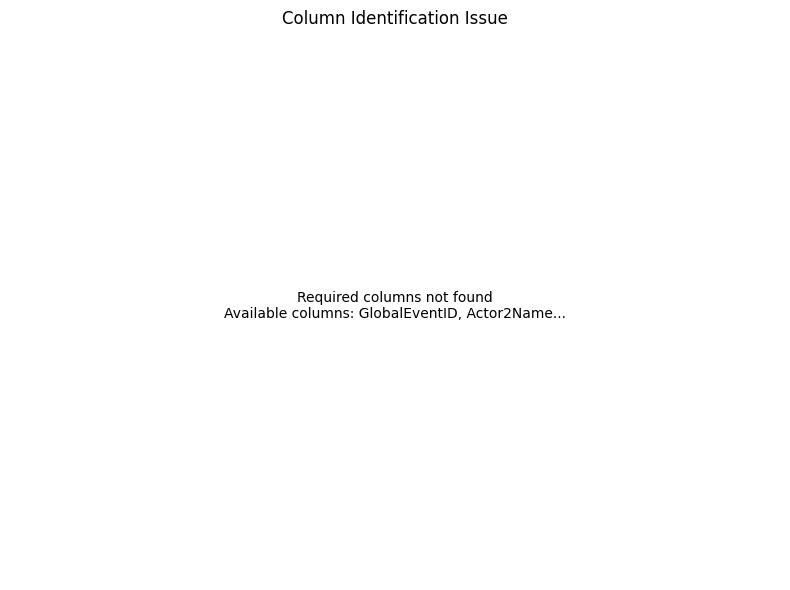

Processing row 629 (38/100)...
Processing row 370 (39/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 309 (40/100)...
Available columns: ['GlobalEventID', 'Actor1Name', 'Actor2Name', 'AvgTone']
Processing row 29 (41/100)...
Processing row 788 (42/100)...
Processing row 578 (43/100)...
Processing row 1304 (44/100)...
Processing row 1107 (45/100)...
Available columns: ['GlobalEventID', 'Actor1Name', 'Actor2Name']
Potential event code columns: ['GlobalEventID']
No data found for event code 131
Creating a sample visualization with available data...


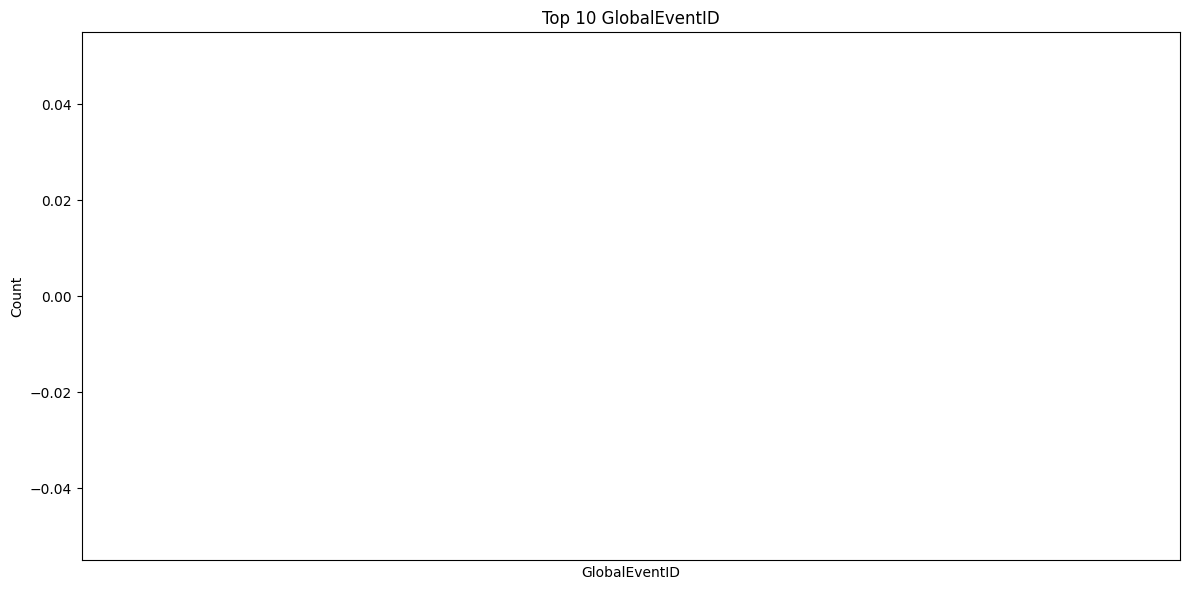

Processing row 984 (46/100)...
Available columns: ['GlobalEventID', 'Actor1Name', 'Actor2Name']
No standard event code column found. Searching for column containing embargo events...
No column found with value 163. Using first column as event code.
Found 0 embargo events with code 163 in column 'GlobalEventID'
No embargo events found with code 163


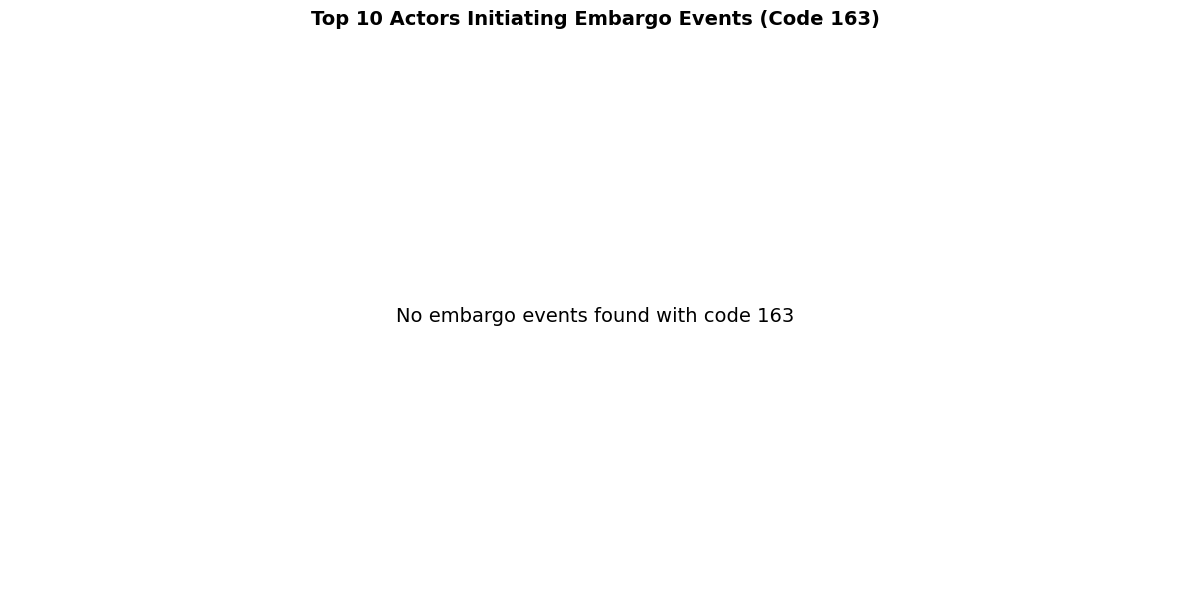

Processing row 1001 (47/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Processing row 1392 (48/100)...
Processing row 244 (49/100)...


<string>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 354 (50/100)...
Processing row 76 (51/100)...


...

Processing row 44 (63/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Processing row 997 (64/100)...
Processing row 101 (65/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 1188 (66/100)...
Processing row 380 (67/100)...
Processing row 867 (68/100)...
Processing row 823 (69/100)...


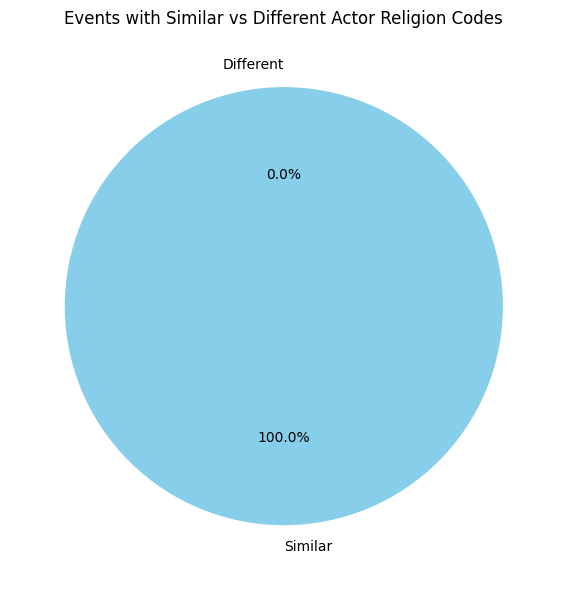

Processing row 1272 (70/100)...
Processing row 1373 (71/100)...
Processing row 239 (72/100)...
Processing row 715 (73/100)...
Processing row 1289 (74/100)...
Available columns: ['GlobalEventID', 'Actor1Name', 'Actor2Name']


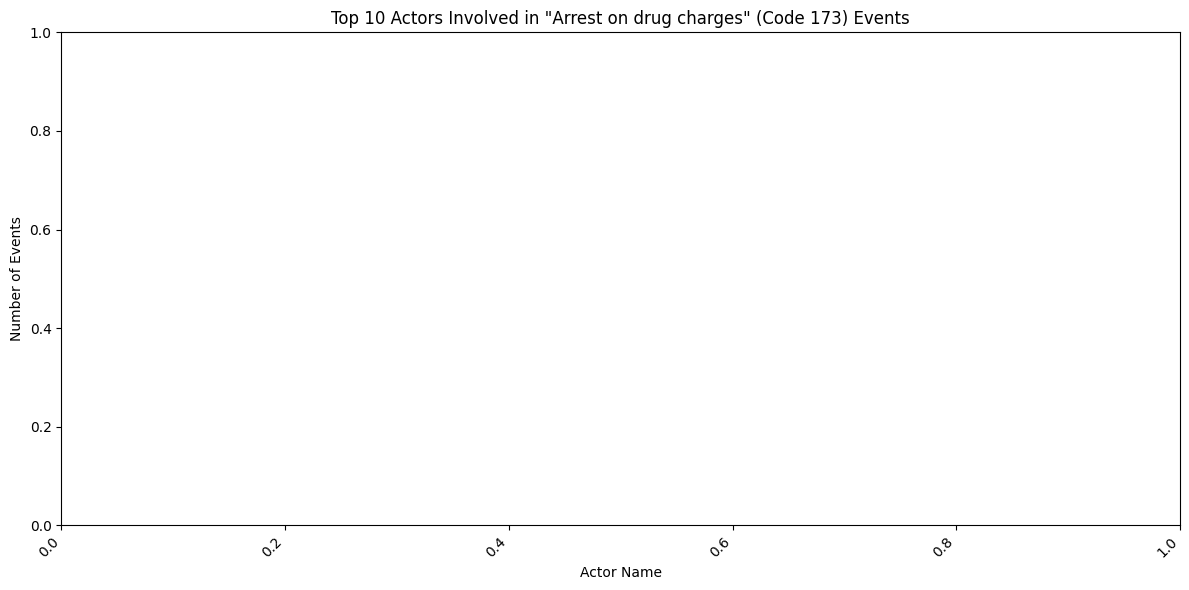

Processing row 1239 (75/100)...
Processing row 198 (76/100)...


<string>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 1229 (77/100)...
Processing row 814 (78/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Processing row 899 (79/100)...


...

Processing row 1400 (96/100)...
Processing row 184 (97/100)...
Processing row 506 (98/100)...


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Processing row 351 (99/100)...
Processing row 818 (100/100)...


,ID,User Request,relevance,information_readability,adaptability,legend_readability,color_choice,total_score,Reasoning
0,51,Événements avec un acteur principal et seconda...,1,1,1,1,1,2.0,The chart accurately represents the requested ...
1,481,Sources qui couvrent des événements avec des d...,1,1,0,0,1,1.3,Relevance: The chart shows sources with consta...
2,806,Top 10 des types d'acteur 2 les plus fréquents...,1,1,1,1,1,2.0,The chart correctly represents the top 10 most...
3,1261,Calcule le ton moyen des événements impliquant...,0,0,0,0,0,0.0,Irrelevant: The chart fails to display any rel...
4,297,Affiche la moyenne du nombre d'articles par év...,1,1,1,1,1,2.0,The chart accurately represents the average nu...
...,...,...,...,...,...,...,...,...,...
95,1400,Comptez le nombre d'événements liés aux mouvem...,0,0,0,0,0,0.0,Irrelevant: The chart fails to represent the r...
96,184,Trouve les 25 événements les plus mentionnés i...,1,1,0,0,0,1.3,The chart correctly represents the top 25 gove...
97,506,Acteurs qui apparaissent dans des événements a...,1,1,0,0,1,1.6,The chart accurately represents the requested ...
98,351,Liste les 20 événements avec la plus grande so...,1,0,0,0,0,0.5,Relevance: The chart shows the top 20 events w...


,ID,User Request,relevance,information_readability,adaptability,legend_readability,color_choice,total_score,Reasoning
0,51,Événements avec un acteur principal et seconda...,1,1,1,1,1,2.0,The chart accurately represents the requested ...
1,481,Sources qui couvrent des événements avec des d...,1,1,0,0,1,1.3,Relevance: The chart shows sources with consta...
2,806,Top 10 des types d'acteur 2 les plus fréquents...,1,1,1,1,1,2.0,The chart correctly represents the top 10 most...
3,1261,Calcule le ton moyen des événements impliquant...,0,0,0,0,0,0.0,Irrelevant: The chart fails to display any rel...
4,297,Affiche la moyenne du nombre d'articles par év...,1,1,1,1,1,2.0,The chart accurately represents the average nu...
...,...,...,...,...,...,...,...,...,...
95,1400,Comptez le nombre d'événements liés aux mouvem...,0,0,0,0,0,0.0,Irrelevant: The chart fails to represent the r...
96,184,Trouve les 25 événements les plus mentionnés i...,1,1,0,0,0,1.3,The chart correctly represents the top 25 gove...
97,506,Acteurs qui apparaissent dans des événements a...,1,1,0,0,1,1.6,The chart accurately represents the requested ...
98,351,Liste les 20 événements avec la plus grande so...,1,0,0,0,0,0.5,Relevance: The chart shows the top 20 events w...


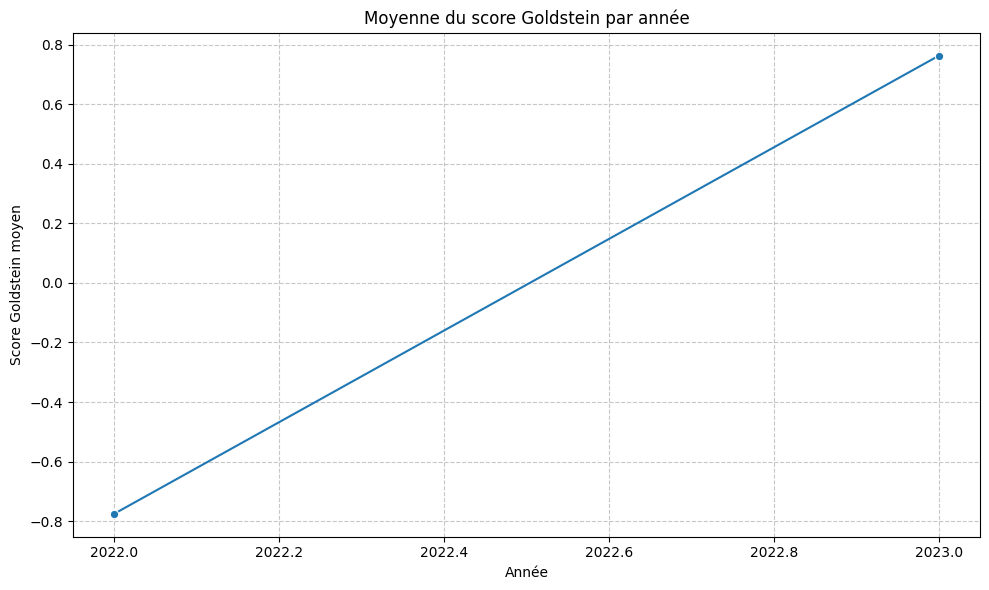

In [ ]:
import sqlite3
import json
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display, Image as IPImage

db_conn = sqlite3.connect(":memory:")
validator.push_to_sqlite(db_conn)
def run_full_pipeline_with_display(dataset_row,show = False):
    sql_query = dataset_row['sql_query']
    viz_code = dataset_row['visualization_code']
    user_request = dataset_row['text_query']
    if show:
      print(f"\n{'='*60}")
      print(f"TASK: {user_request}")
      print(f"{'='*60}")

    try:
        df_result = pd.read_sql_query(sql_query, db_conn)
    except Exception as e:
        return 0.0, f"SQL Error: {str(e)}"

    plt.close('all')
    exec_globals = {
        'pd': pd,
        'plt': plt,
        'np': np,
        'sns': sns,
        'df': df_result
    }

    try:
        exec(viz_code, exec_globals)

        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        if show:
          print(">> Generated Plot:")
          display(IPImage(data=buf.getvalue()))

        buf.seek(0)
        img_for_vlm = Image.open(buf).convert("RGB")

    except Exception as e:
        return 0.0, f"Viz Execution Error: {str(e)}"
    if show:
      print(">> Calling VLM Judge...")
    prompt_wrapper = f"<|im_start|>user\nUser Request: {user_request}\n<|im_end|>"
    scores, reasoning = vlm_evaluate_image(prompt_wrapper, img_for_vlm,return_details=True)

    return scores, reasoning

df_sample = df_gt.sample(n=100, random_state=42)

results = []

for index, row in df_sample.iterrows():
    print(f'Processing row {index} ({len(results)+1}/100)...')

    scores, reason = run_full_pipeline_with_display(row, show=False)

    results.append({
        "ID": index,
        "User Request": row['text_query'][:50] + "...",
        'relevance': int(scores[0]),
        'information_readability': int(scores[1]),
        'adaptability': int(scores[2]),
        'legend_readability': int(scores[3]),
        'color_choice': int(scores[4]),
        "total_score": float(scores[-1]),
        "Reasoning": reason
    })

summary_df = pd.DataFrame(results)
display(summary_df)

summary_df = pd.DataFrame(results)
display(summary_df)

In [ ]:
summary_df
summary_df.to_csv('results.csv', index=False)

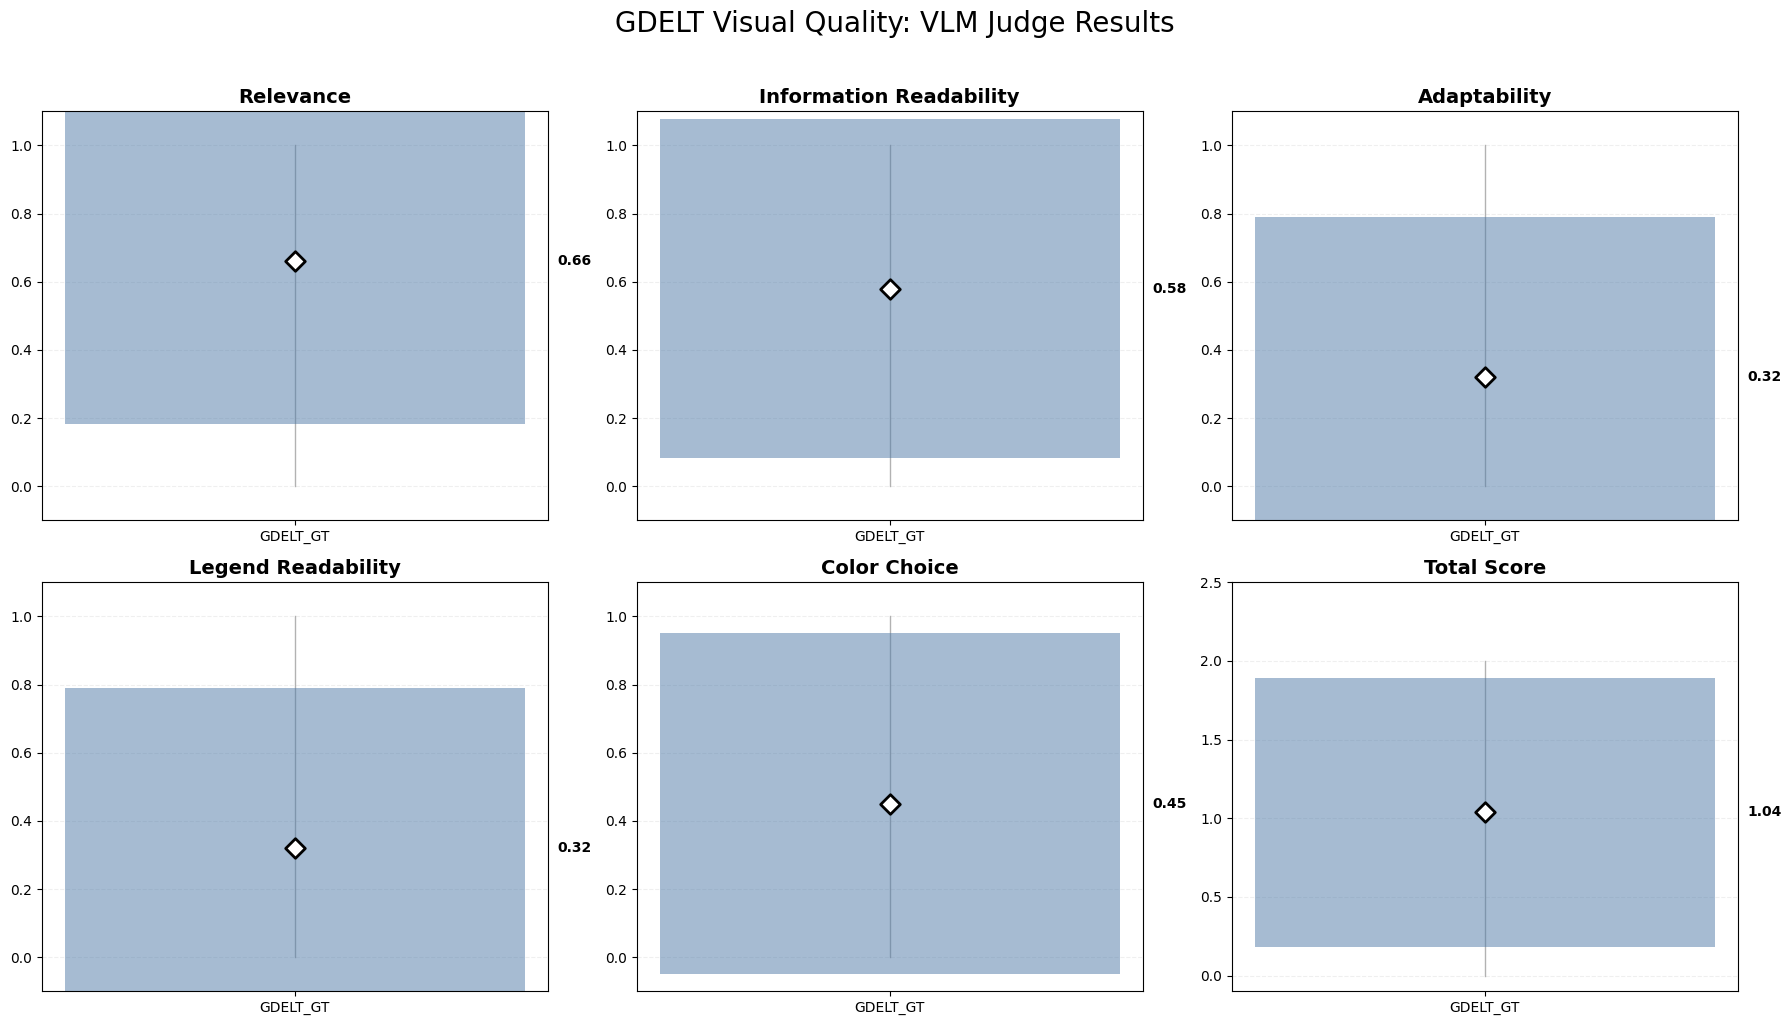

In [ ]:
def plot_vlm_judge_distributions(list_results_df, model_names):
    metrics = [
        'relevance',
        'information_readability',
        'adaptability',
        'legend_readability',
        'color_choice',
        'total_score'
    ]

    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
    axes = axes.flatten()

    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
    bar_width = 0.35

    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        pretty_metric = metric.replace('_', ' ').title()

        for i, df in enumerate(list_results_df):
            if metric not in df.columns:
                continue

            series = df[metric].dropna().astype(float)
            mean_val = series.mean()
            std_val = series.std() if len(series) > 1 else 0
            min_val = series.min()
            max_val = series.max()

            x = i
            color = colors[i % len(colors)]

            ax.plot([x, x], [min_val, max_val], color='black', linewidth=1, alpha=0.3, zorder=1)

            rect_bottom = mean_val - std_val
            ax.bar(x, 2 * std_val, bottom=rect_bottom, width=bar_width,
                   color=color, alpha=0.5, label=model_names[i] if ax_idx==0 else "", zorder=2)

            ax.scatter(x, mean_val, color='white', edgecolor='black', s=100, linewidth=2, zorder=3, marker='D')
            ax.text(x + 0.2, mean_val, f"{mean_val:.2f}", fontsize=10, va='center', fontweight='bold')

        ax.set_title(pretty_metric, fontsize=14, fontweight='bold')
        ax.set_xticks(range(len(model_names)))
        ax.set_xticklabels(model_names)

        if metric == 'total_score':
            ax.set_ylim(-0.1, 2.5)
        else:
            ax.set_ylim(-0.1, 1.1)

        ax.grid(axis='y', linestyle='--', alpha=0.2)

    plt.suptitle("GDELT Visual Quality: VLM Judge Results", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

plot_vlm_judge_distributions([summary_df], ['GDELT_GT'])

In [ ]:
import ast
import io
import contextlib
import matplotlib
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForImageTextToText

matplotlib.use('Agg')

def check_syntax(code_str):
    """
    Returns True if code_str is valid Python syntax, False otherwise.
    Uses 'ast.parse' which checks grammar without executing.
    """
    try:
        ast.parse(code_str)
        return True
    except SyntaxError:
        return False

def check_execution_and_plot(code_str):
    """
    Executes code and checks if a matplotlib figure was created.
    Returns: (success: bool, image: PIL.Image|None)
    """
    buffer = io.BytesIO()
    exec_globals = {}

    try:
        plt.close('all')

        with contextlib.redirect_stdout(io.StringIO()):
            exec(code_str, exec_globals)

        if plt.get_fignums():
            plt.savefig(buffer, format='png', bbox_inches='tight')
            buffer.seek(0)
            img = Image.open(buffer).convert("RGB")
            plt.close('all')
            return True, img
        else:
            return False, None

    except Exception as e:
        return False, None


def python_syntax_reward(completions, **kwargs):
    """
    Reward for valid Python syntax.
    """
    rewards = []
    for code in completions:
        if check_syntax(code):
            rewards.append(0.0)
        else:
            rewards.append(-1.0)
    return rewards

def plot_success_reward(completions, **kwargs):
    """
    Reward for successful execution AND generating a plot.
    """
    rewards = []
    for code in completions:
        success, _ = check_execution_and_plot(code)
        if success:
            rewards.append(0.0)
        else:
            rewards.append(-0.5)
    return rewards


def combined_reward_pipeline(prompts, completions, answer, **kwargs):
    """
    Master function that chains checks:
    Syntax -> Execution -> VLM
    """
    rewards = []

    for prompt, code, gold in zip(prompts, completions, answer):

        # 1. Syntax Check
        if not check_syntax(code):
            rewards.append(-1.0)
            continue

        success, generated_image = check_execution_and_plot(code)

        if not success:
            rewards.append(-0.5)
            continue

        vlm_score_list = vlm_evaluate_image(
            [prompt],
            [generated_image],
            [gold]
        )
        rewards.append(vlm_score_list[0])

    return rewards

In [ ]:
import pandas as pd
import json
from datasets import Dataset, DatasetDict

INPUT_CSV = "/content/gdelt_viz_dataset.csv"
OUTPUT_HF_PATH = "/content/processed_viz_dataset_hf"

def get_data_snapshot(json_data):
    try:
        data_list = json.loads(json_data)
        df = pd.DataFrame(data_list)
        if df.empty: return "Data is empty."

        data_head = df.head(5).to_markdown(index=False)
        data_types = ", ".join([f"{col} ({dtype})" for col, dtype in df.dtypes.items()])

        return f"[DATA PREVIEW]\n{data_head}\n\n[COLUMN TYPES]\n{data_types}"
    except Exception:
        return "Error parsing data context."

def format_for_grpo(row):
    system_message = (
        "You are a Python Data Visualization Expert. "
        "Generate a complete Python code block using matplotlib or seaborn to visualize the user's data.\n"
        "Rules:\n"
        "1. Assume the data is already loaded into a pandas DataFrame named `df`.\n"
        "2. DO NOT include code to read CSV files.\n"
        "3. Output ONLY the python code."
    )

    data_context = get_data_snapshot(row['query_result'])
    user_message = (
        f"User Query: {row['text_query']}\n\n"
        f"Here is the data result from the SQL query:\n"
        f"{data_context}"
    )

    prompt_text = (
        f"<|im_start|>system\n{system_message}<|im_end|>\n"
        f"<|im_start|>user\n{user_message}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    answer_text = row['visualization_code']

    return {"prompt": prompt_text, "answer": answer_text}

print(f"Loading Dataset from {INPUT_CSV}")
df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['visualization_code', 'query_result'])
df = df[df['query_result'].str.len() > 5]

formatted_data = df.apply(format_for_grpo, axis=1, result_type='expand')
df = pd.concat([df, formatted_data], axis=1)

full_dataset = Dataset.from_pandas(df[['prompt', 'answer']])

train_split = full_dataset.train_test_split(test_size=0.1, seed=42)
dataset = DatasetDict({
    'train': train_split['train'],
    'test': train_split['test']
})

print(f"Train Size: {len(dataset['train'])}")
print(f"Test Size:  {len(dataset['test'])}")
print(f"Columns: {dataset['train'].column_names}") # Should be ['prompt', 'answer']

dataset.save_to_disk(OUTPUT_HF_PATH)
print(f"Saved GRPO dataset to {OUTPUT_HF_PATH}")

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
TRAINING_MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"

print("Loading Training Model (Qwen) in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    TRAINING_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM",
    bias="none"
)
model = get_peft_model(model, peft_config)

tokenizer = AutoTokenizer.from_pretrained(TRAINING_MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

get_molmo_model()

training_args = GRPOConfig(
    output_dir="grpo_chart_model",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    num_generations=4,
    max_completion_length=512,
    beta=0.1,
    fp16=False,
    bf16=True,
    logging_steps=5,
    report_to="none"
)

trainer = GRPOTrainer(
    model=model,
    reward_funcs=[combined_reward_pipeline],
    args=training_args,
    train_dataset=dataset['train'],
    peft_config=peft_config,
    processing_class=tokenizer,
)

print("Starting GRPO Training...")
trainer.train()